In [1]:
import json

import pandas as pd
from pandas.core.common import random_state
from sklearn.model_selection import train_test_split

import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import torch.nn as nn

In [2]:
path_to_labels = '../cassava-leaf-disease-classification/train.csv'

df = pd.read_csv(path_to_labels) # Read the labels

In [10]:
# Forming 80/10/10 train, validate, test splits

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# Ensuring batches are disjoint from one another and that all batches add up to 100%

assert len(train_df) + len(val_df) + len(test_df) == len(df)

assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)

In [4]:
class CassavaDataset(Dataset):
    """
    Initializing the dataset structure, this class inherits torch.utils.data.Dataset.
    The __init__ method will define the attributes of the dataset, and initialize any transformation needed.
    __len__ will return the number of images in the dataset. Finally, __getitem__ will get the label and image being requested.
    Once retrieved, the image will undergo any needed transformation. Once transformations are done, return the image and label.
    """
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = os.path.join(self.image_dir, row["image_id"])

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label, image_path


In [5]:
train_transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.uint8, scale=False)])
val_transform = None
test_transform = None

image_dir = '../cassava-leaf-disease-classification/train_images'

train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)
test_dataset = CassavaDataset(test_df, image_dir, test_transform)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
import matplotlib.pyplot as plt

images, labels, file_path = next(iter(train_loader))

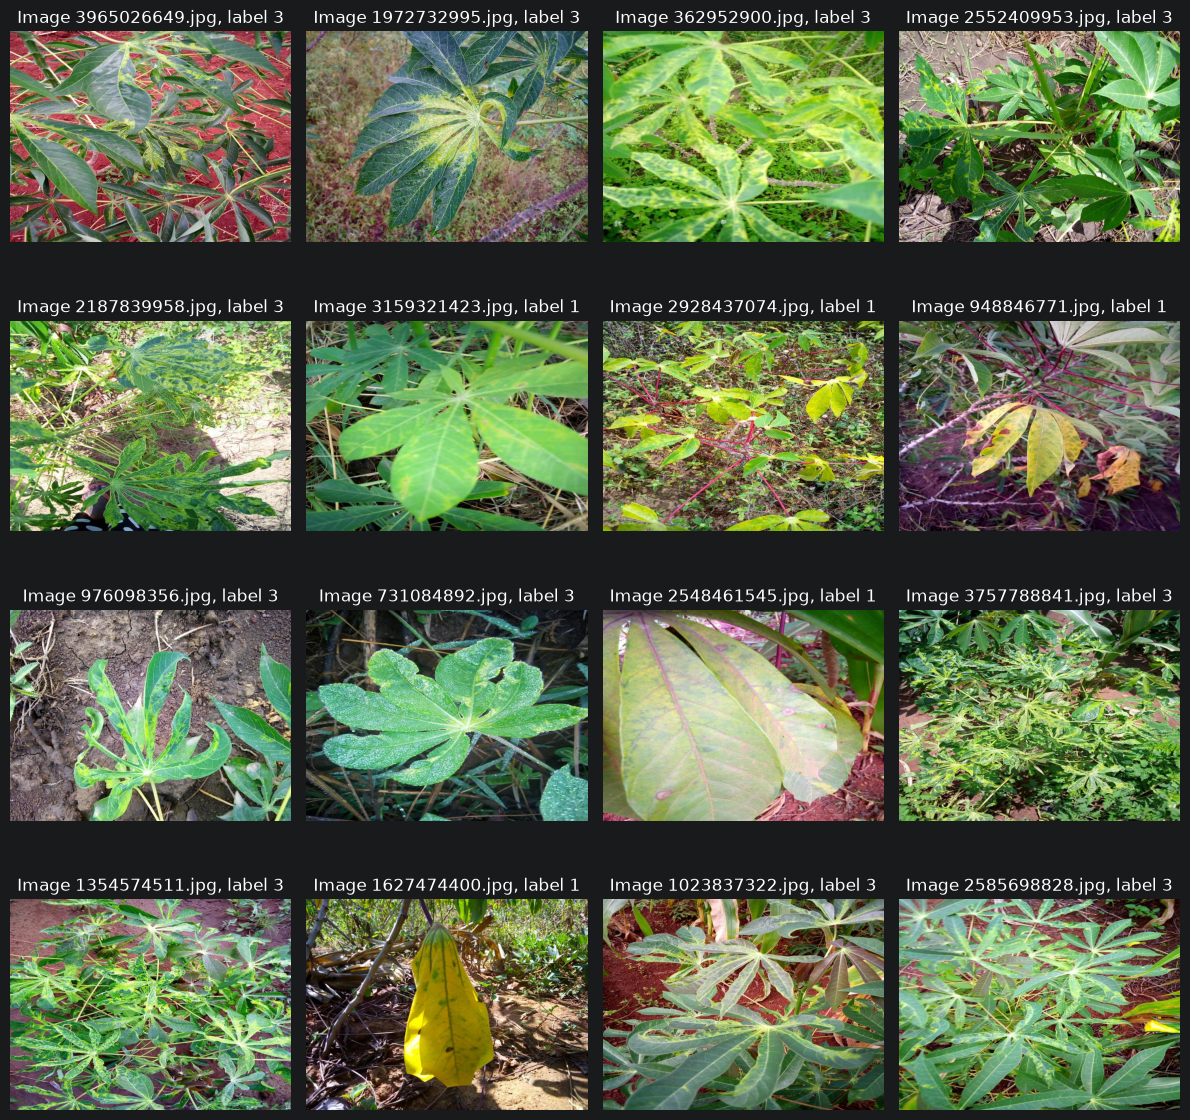

In [8]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    for j in range(4):
        idx = (i * 4) + j
        im = images[idx, ...].permute(1, 2, 0).numpy()
        axs[i, j].imshow(im)
        axs[i, j].axis('off')
        axs[i, j].set_title(f"Image {str(file_path[idx].split("/")[-1])}, label {str(labels[idx].item())}")

plt.tight_layout()
plt.show()

In [9]:
print(f"General Statistics:\n++++++++++++++++++++++++++++++++++++++++=\n"
      f"Heigh of Images: {images.shape[2]}\n"
      f"Width of Images: {images.shape[3]}\n"
      f"Number of Images in Train: {len(train_dataset)}\n"
      f"Number of Images in Validation: {len(val_dataset)}\n"
      f"Number of Images in Test: {len(test_dataset)}\n")

General Statistics:
++++++++++++++++++++++++++++++++++++++++=
Heigh of Images: 600
Width of Images: 800
Number of Images in Train: 17117
Number of Images in Validation: 2140
Number of Images in Test: 2140

